Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

Load Dataset

In [2]:
df = pd.read_csv("/content/student_performance_dataset.csv")

Display Dataset

In [3]:
print(df.head())
print(df.info())

  Student_ID  Gender  Study_Hours_per_Week  Attendance_Rate  Past_Exam_Scores  \
0       S147    Male                    31        68.267841                86   
1       S136    Male                    16        78.222927                73   
2       S209  Female                    21        87.525096                74   
3       S458  Female                    27        92.076483                99   
4       S078  Female                    37        98.655517                63   

  Parental_Education_Level Internet_Access_at_Home Extracurricular_Activities  \
0              High School                     Yes                        Yes   
1                      PhD                      No                         No   
2                      PhD                     Yes                         No   
3                Bachelors                      No                         No   
4                  Masters                      No                        Yes   

   Final_Exam_Score Pass_F

Data Cleaning


In [4]:
df.drop_duplicates(inplace=True)
df.dropna(inplace=True)

Remove Student_ID

In [5]:
df = df.drop("Student_ID", axis=1)

 Encode Categorical Columns

In [6]:
le = LabelEncoder()

categorical_cols = [
    'Gender',
    'Parental_Education_Level',
    'Internet_Access_at_Home',
    'Extracurricular_Activities',
    'Pass_Fail'
]

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

 EDA

Pass vs Fail Distribution

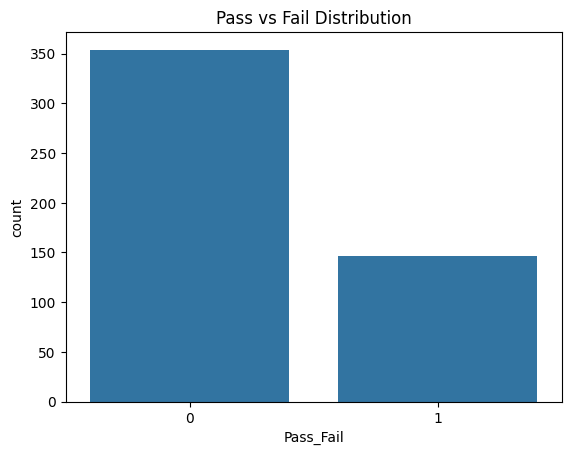

In [7]:
sns.countplot(x='Pass_Fail', data=df)
plt.title("Pass vs Fail Distribution")
plt.show()

Study Hours Distribution

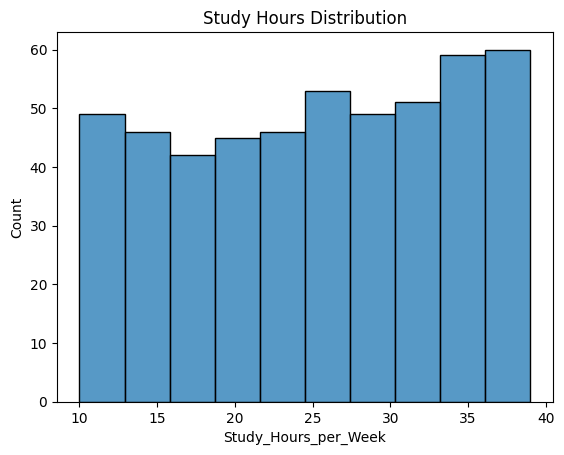

In [8]:
sns.histplot(df['Study_Hours_per_Week'], bins=10)
plt.title("Study Hours Distribution")
plt.show()

Attendance Distribution

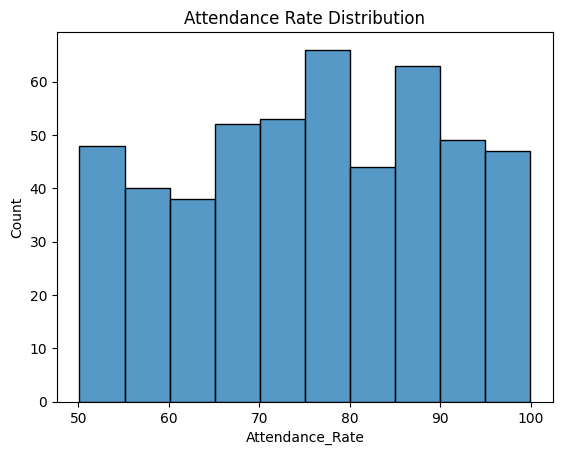

In [9]:
sns.histplot(df['Attendance_Rate'], bins=10)
plt.title("Attendance Rate Distribution")
plt.show()

Study Hours vs Final Score

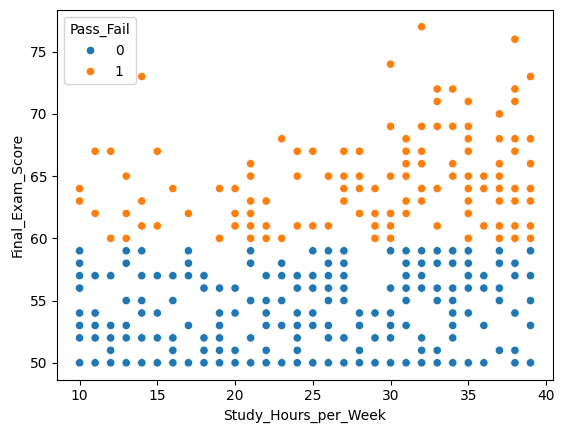

In [10]:
sns.scatterplot(
    x='Study_Hours_per_Week',
    y='Final_Exam_Score',
    hue='Pass_Fail',
    data=df
)
plt.show()

Correlation Heatmap

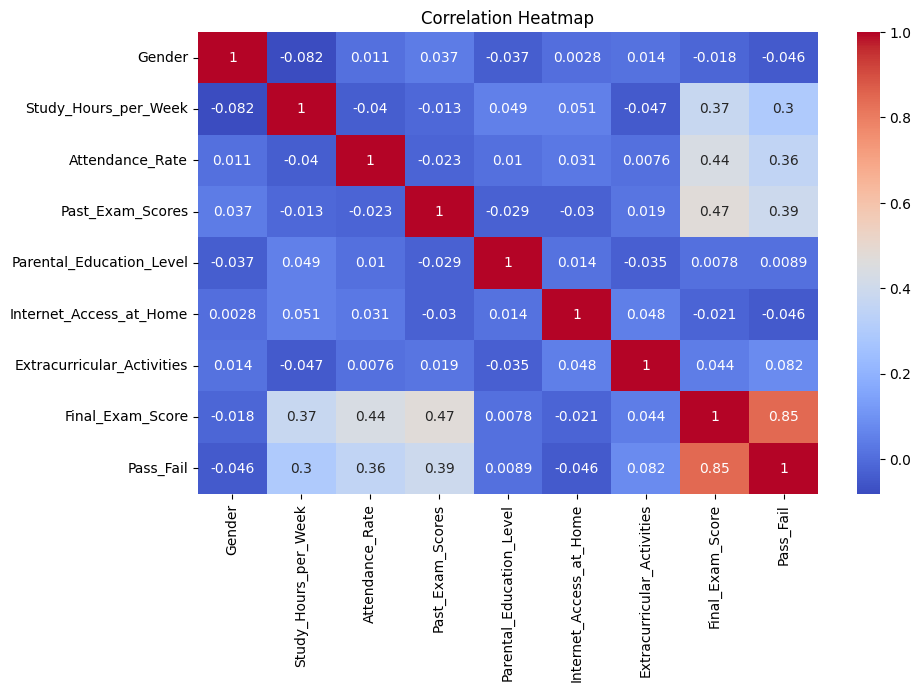

In [11]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

Logistic Regression

In [12]:
X = df.drop('Pass_Fail', axis=1)
y = df['Pass_Fail']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

Evaluation

In [13]:
print("Accuracy Score:")
print(accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy Score:
0.99

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99        75
           1       1.00      0.96      0.98        25

    accuracy                           0.99       100
   macro avg       0.99      0.98      0.99       100
weighted avg       0.99      0.99      0.99       100


Confusion Matrix:
[[75  0]
 [ 1 24]]
